In [1]:
# Late delivery prediction (Regression/Classification models)
# Classification (predicting if a delay will happen: yes/no) and Regression (predicting the duration of the delay in days/hours)


#Import Machine Learning Libraries & Load Data

import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Paths
BASE_DIR = os.path.dirname(os.path.abspath(""))
DB_PATH = os.path.join(BASE_DIR, "data-package", "database", "afilearn_commerce_master.db")

# Load our clean production tables
conn = sqlite3.connect(DB_PATH)
df_orders = pd.read_sql_query("SELECT order_id, order_purchase_timestamp, is_late_delivery FROM prod_orders_cleaned;", conn)
df_items = pd.read_sql_query("SELECT order_id, price, freight_value FROM prod_items_cleaned;", conn)
conn.close()

# Merge features on order_id
df_ml = pd.merge(df_orders, df_items, on="order_id", how="inner")
print(f"✔ Features loaded successfully. Dataset dimensions: {df_ml.shape[0]:,} rows | {df_ml.shape[1]} columns")

✔ Features loaded successfully. Dataset dimensions: 110,196 rows | 5 columns


In [3]:
#Feature Engineering & Preprocessing for ML
# Convert purchase timestamp to extract time-series features
df_ml['order_purchase_timestamp'] = pd.to_datetime(df_ml['order_purchase_timestamp'])
df_ml['purchase_hour'] = df_ml['order_purchase_timestamp'].dt.hour
df_ml['purchase_day_of_week'] = df_ml['order_purchase_timestamp'].dt.dayofweek

# Define our feature matrix (X) and target vector (y)
feature_cols = ['price', 'freight_value', 'purchase_hour', 'purchase_day_of_week']
X = df_ml[feature_cols]
y = df_ml['is_late_delivery']

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (Scaling is crucial for Logistic Regression model convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✔ Preprocessing complete.")
print(f"  - Training Set: {X_train.shape[0]:,} samples")
print(f"  - Testing Set: {X_test.shape[0]:,} samples")

✔ Preprocessing complete.
  - Training Set: 88,156 samples
  - Testing Set: 22,040 samples


In [4]:
#Train Classifier Models (Logistic Regression & Random Forest)
print("--- [Step 1] Training Baseline Logistic Regression Classifier ---")
lr_model = LogisticRegression(random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- [Step 2] Training Advanced Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10)
rf_model.fit(X_train, y_train)  # Random Forest does not require scaled inputs
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n✔ Both model architectures trained successfully.")

--- [Step 1] Training Baseline Logistic Regression Classifier ---

--- [Step 2] Training Advanced Random Forest Classifier ---

✔ Both model architectures trained successfully.


=== MODEL PERFORMANCE EVALUATION ===
Logistic Regression Accuracy: 0.6593
Random Forest Accuracy:       0.5250

=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     20587
           1       0.08      0.39      0.13      1453

    accuracy                           0.66     22040
   macro avg       0.51      0.53      0.46     22040
weighted avg       0.88      0.66      0.74     22040



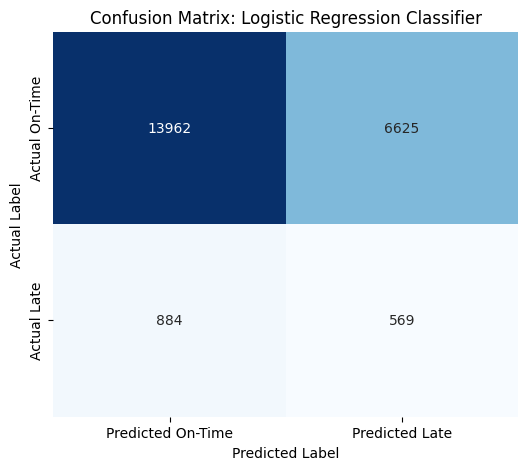

In [5]:
#Evaluate Model Performance & Generate Confusion Matrix
# Compare Accuracies
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("=== MODEL PERFORMANCE EVALUATION ===")
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Random Forest Accuracy:       {acc_rf:.4f}\n")

print("=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_lr))

# Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted On-Time', 'Predicted Late'],
            yticklabels=['Actual On-Time', 'Actual Late'])
plt.title("Confusion Matrix: Logistic Regression Classifier")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")

# Save Confusion Matrix visual directly to dashboards screenshots
cm_path = os.path.join(BASE_DIR, "dashboards", "screenshots", "supervised_confusion_matrix.png")
plt.savefig(cm_path, bbox_inches='tight', dpi=300)
plt.show()